In [52]:
import numpy as np
#from scipy.special import gammaln # Para calcular log(Gamma(alpha))
#from scipy.stats import gamma
import matplotlib.pyplot as plt


class PoissonRegression:
    def __init__(self, alpha=0.1, lr=0.001, n_iter=10000, tol=1e-6):
        # Inicializo la clase
        self.alpha = alpha
        self.lr = lr
        self.n_iter = n_iter
        self.tol = tol
        self.theta = None
    def grad(self, X, y, theta):
        sub_eta = X.dot(theta)
        loss = np.sum( np.exp(sub_eta) * y - self.alpha * sub_eta)
        # [:, None] convierte el vector en un vector vertical
        # axis = 0 hace que se sumen los elementos de cada columna
        grad = np.sum((( y * np.exp(sub_eta) - self.alpha )[:, None]) * X, axis=0)
        return loss, grad
    def fit(self, X, y):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        n,m = X.shape
        # Inicializamos theta en ceros
        theta = np.zeros(m)
        prev_loss = np.inf
        # Hago el descenso por gradiente
        for iteration in range(self.n_iter):
            loss, grad = self.grad(X, y, theta)
            theta = theta - self.lr * grad
            # Verificar convergencia
            if np.abs(prev_loss - loss) < self.tol:
                print(f"Convergencia alcanzada en la iteración {iteration}")
                break
            prev_loss = loss
        self.theta = theta
    def predict(self, X):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        if self.theta is None:
            raise ValueError("El modelo no ha sido ajustado. Llama a fit() primero.")
        eta = np.exp(X.dot(self.theta))
        return self.alpha/eta
    def loss(self, X, y):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        eta = np.exp(X.dot(self.theta))
        res = - self.alpha * np.log(eta) - eta*y + (self.alpha - 1)*np.log(y) - gammaln(self.alpha)
        return np.sum(res)


In [53]:
import numpy as np

class PoissonRegression:
    def __init__(self, lr=1e-6, n_iter=10000, tol=1e-8):
        # Inicializo la clase
        # Tasa de aprendizaje (step size del descenso por gradiente)
        self.lr = lr
        
        # Número máximo de iteraciones del algoritmo
        self.n_iter = n_iter
        
        # Tolerancia mínima de cambio en la log-verosimilitud para detener entrenamiento
        self.tol = tol

        # Parámetros del modelo (se inicializarán al entrenar)
        self.theta = None

        # Lista para almacenar la log-verosimilitud en cada iteración (útil para graficar)
        self.log_likelihood_history = []

    def _log_likelihood(self, X, y, theta):
        # η = Xθᵀ (parámetro natural)
        eta = X.dot(theta)

        # μ = exp(η) (esperanza de y|x según GLM Poisson)
        mu = np.exp(eta)

        # Log-verosimilitud sin término constante (omitimos log(y!))
        # Fórmula: sum(y_i * log(mu_i) - mu_i)
        return np.sum(y * eta - mu)

    def _gradient(self, X, y, theta):
        # μ = exp(Xθᵀ)
        mu = np.exp(X.dot(theta))
        if np.isnan(mu).any():
            raise ValueError("Overflow en la exponencial.")

        # Gradiente de la log-verosimilitud respecto a θ:
        # ∇l(θ) = Xᵀ (y - μ)
        return X.T.dot((y - mu))

    def fit(self, X, y):
        # Añadimos un 1 al principio de cada fila de X para el término independiente (bias/intercepto)
        X = np.hstack([np.ones((X.shape[0], 1)), X])

        # Inicializamos los parámetros θ en ceros
        self.theta = np.zeros(X.shape[1])

        prev_ll = -np.inf  # Inicializamos log-verosimilitud previa

        for i in range(self.n_iter):
            # Calculamos el gradiente de la log-verosimilitud
            grad = self._gradient(X, y, self.theta)

            # Actualizamos θ usando descenso por gradiente
            self.theta += self.lr * grad

            # Calculamos la nueva log-verosimilitud
            ll = self._log_likelihood(X, y, self.theta)

            # Guardamos para graficar o monitorear
            self.log_likelihood_history.append(ll)

            # Verificamos convergencia
            if abs(ll - prev_ll) < self.tol:
                print(f"Convergencia alcanzada en la iteración {i}")
                break

            prev_ll = ll

    #def predict(self, X):
    #    # Preparamos X con el término independiente
    #    X = np.hstack([np.ones((X.shape[0], 1)), X])
    #
    #    # Predicción: μ = exp(Xθᵀ)
    #    return np.exp(X.dot(self.theta))
    def predict(self, X):
        """Versión corregida del método predict que maneja el overflow de np.exp."""
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        eta = X.dot(self.theta)
    
        # Prevenir overflow de np.exp
        eta = np.clip(eta, a_min=-700, a_max=20)  # límites seguros para exp

        return np.exp(eta)


In [54]:
import pandas as pd
# Importo los datos
Data = pd.read_csv(r"Datos/Poisson_Train.csv")
X = Data[["x_1","x_2","x_3","x_4"]].values
y = Data["y"].values
model = PoissonRegression(lr=0.001, n_iter=10000, tol=1e-6)
model.fit(X, y)
# Grafico los resultados
plt.scatter(y,model.predict(X))
# Calculo el R^2
from sklearn.metrics import r2_score
print("¿NaNs en y?:", np.isnan(y).any())
y_pred = model.predict(X)
print("¿NaNs en en las predicciones?:", np.isnan(y_pred).any())
print("¿Hay infinitos en las predicciones?:", np.isinf(y_pred).any())
print("Índices con NaN en predicciones:")
print(np.where(np.isnan(y_pred))[0])
"""lo presenta nans en las predicciones debido a un overflow en la exponencial
de la función de enlace, lo que puede suceder si los valores de X son muy grandes o si los parámetros theta son muy grandes.
modificando el learning rate a 0.01 se soluciona el problema para que converja antes de que se produzcan nans"""
"""continuamos teniendo nans en las predicciones, por lo que modificamos el método predict para evitar el overflow de np.exp 
pero vemos que en el fit tambien exp tiene un overflow, por lo que optaremos por regresar al modelo de PoissonRegression original y normalizar los datos antes de entrenar el modelo"""

print(r2_score(y,y_pred))
# 0.98

C:\Users\Juan\AppData\Local\Temp\ipykernel_10672\3588469396.py:26: RuntimeWarning: overflow encountered in exp
  mu = np.exp(eta)
C:\Users\Juan\AppData\Local\Temp\ipykernel_10672\3588469396.py:65: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(ll - prev_ll) < self.tol:
C:\Users\Juan\AppData\Local\Temp\ipykernel_10672\3588469396.py:34: RuntimeWarning: overflow encountered in exp
  mu = np.exp(X.dot(theta))


ValueError: Overflow en la exponencial.

continuamos teniendo nans en las predicciones, por lo que modificamos el método predict para evitar el overflow de np.exp 
pero vemos que en el fit tambien exp tiene un overflow, por lo que optaremos por regresar al modelo de PoissonRegression original y normalizar los datos antes de entrenar el modelo

In [55]:
import numpy as np

class PoissonRegression:
    def __init__(self, lr=1e-6, n_iter=10000, tol=1e-8):
        # Inicializo la clase
        # Tasa de aprendizaje (step size del descenso por gradiente)
        self.lr = lr
        
        # Número máximo de iteraciones del algoritmo
        self.n_iter = n_iter
        
        # Tolerancia mínima de cambio en la log-verosimilitud para detener entrenamiento
        self.tol = tol

        # Parámetros del modelo (se inicializarán al entrenar)
        self.theta = None

        # Lista para almacenar la log-verosimilitud en cada iteración (útil para graficar)
        self.log_likelihood_history = []

    def _log_likelihood(self, X, y, theta):
        # η = Xθᵀ (parámetro natural)
        eta = X.dot(theta)

        # μ = exp(η) (esperanza de y|x según GLM Poisson)
        mu = np.exp(eta)

        # Log-verosimilitud sin término constante (omitimos log(y!))
        # Fórmula: sum(y_i * log(mu_i) - mu_i)
        return np.sum(y * eta - mu)

    def _gradient(self, X, y, theta):
        # μ = exp(Xθᵀ)
        mu = np.exp(X.dot(theta))

        # Gradiente de la log-verosimilitud respecto a θ:
        # ∇l(θ) = Xᵀ (y - μ)
        return X.T.dot((y - mu))

    def fit(self, X, y):
        # Añadimos un 1 al principio de cada fila de X para el término independiente (bias/intercepto)
        X = np.hstack([np.ones((X.shape[0], 1)), X])

        # Inicializamos los parámetros θ en ceros
        self.theta = np.zeros(X.shape[1])

        prev_ll = -np.inf  # Inicializamos log-verosimilitud previa

        for i in range(self.n_iter):
            # Calculamos el gradiente de la log-verosimilitud
            grad = self._gradient(X, y, self.theta)

            # Actualizamos θ usando descenso por gradiente
            self.theta += self.lr * grad

            # Calculamos la nueva log-verosimilitud
            ll = self._log_likelihood(X, y, self.theta)

            # Guardamos para graficar o monitorear
            self.log_likelihood_history.append(ll)

            # Verificamos convergencia
            if abs(ll - prev_ll) < self.tol:
                print(f"Convergencia alcanzada en la iteración {i}")
                break

            prev_ll = ll

    def predict(self, X):
        # Preparamos X con el término independiente
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    
        # Predicción: μ = exp(Xθᵀ)
        return np.exp(X.dot(self.theta))



Media de X_scaled: [ 7.10542736e-18  1.12621024e-16  9.94759830e-18 -1.05160325e-16]
Desviación estándar de X_scaled: [1. 1. 1. 1.]
Mínimo de X_scaled: [-0.63413819 -1.57694336 -1.71065794 -1.72187082]


C:\Users\Juan\AppData\Local\Temp\ipykernel_10672\675690533.py:26: RuntimeWarning: overflow encountered in exp
  mu = np.exp(eta)
C:\Users\Juan\AppData\Local\Temp\ipykernel_10672\675690533.py:63: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(ll - prev_ll) < self.tol:
C:\Users\Juan\AppData\Local\Temp\ipykernel_10672\675690533.py:34: RuntimeWarning: overflow encountered in exp
  mu = np.exp(X.dot(theta))


¿NaNs en y?: False
¿NaNs en las predicciones?: True
¿Hay infinitos en las predicciones?: False
Índices con NaN en predicciones:
[   0    1    2 ... 2497 2498 2499]


ValueError: Input contains NaN.

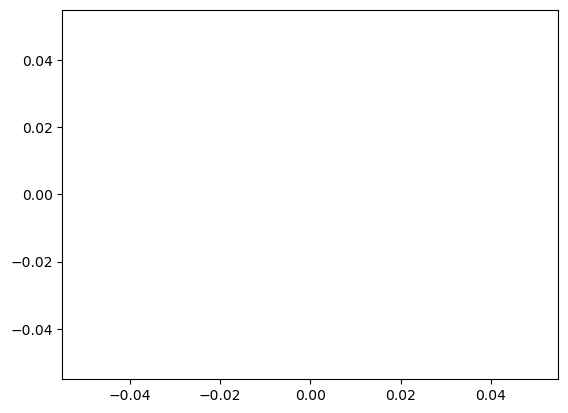

In [57]:
# Normalizamos los datos
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# estadísticas de X_scaled
print("Media de X_scaled:", np.mean(X_scaled, axis=0)) 
print("Desviación estándar de X_scaled:", np.std(X_scaled, axis=0))
print("Mínimo de X_scaled:", np.min(X_scaled, axis=0))
# Entrenamos el modelo con los datos normalizados
model = PoissonRegression(lr=0.01, n_iter=10000, tol=1e-6)
model.fit(X_scaled, y)
# Grafico los resultados
plt.scatter(y, model.predict(X_scaled))
# Calculo el R^2
from sklearn.metrics import r2_score
print("¿NaNs en y?:", np.isnan(y).any())
y_pred = model.predict(X_scaled)
print("¿NaNs en las predicciones?:", np.isnan(y_pred).any())
print("¿Hay infinitos en las predicciones?:", np.isinf(y_pred).any())
print("Índices con NaN en predicciones:")
print(np.where(np.isnan(y_pred))[0])
"""Ahora no tenemos nans en las predicciones, por lo que podemos calcular el r2"""
print(r2_score(y, y_pred))


In [ ]:
# Verificamos si hay NaNs en el DataFrame
print("Cantidad de NaNs en cada columna:")
print(Data.isna().sum())
# Verificamos la proporción de NaNs en cada columna
print("Proporción de NaNs en cada columna:")
print(Data.isna().mean())

Cantidad de NaNs en cada columna:
x_1    0
x_2    0
x_3    0
x_4    0
y      0
dtype: int64
Proporción de NaNs en cada columna:
x_1    0.0
x_2    0.0
x_3    0.0
x_4    0.0
y      0.0
dtype: float64


Media: 3525432.07, Mediana: 1514822.00, Desviación estándar: 5195813.90


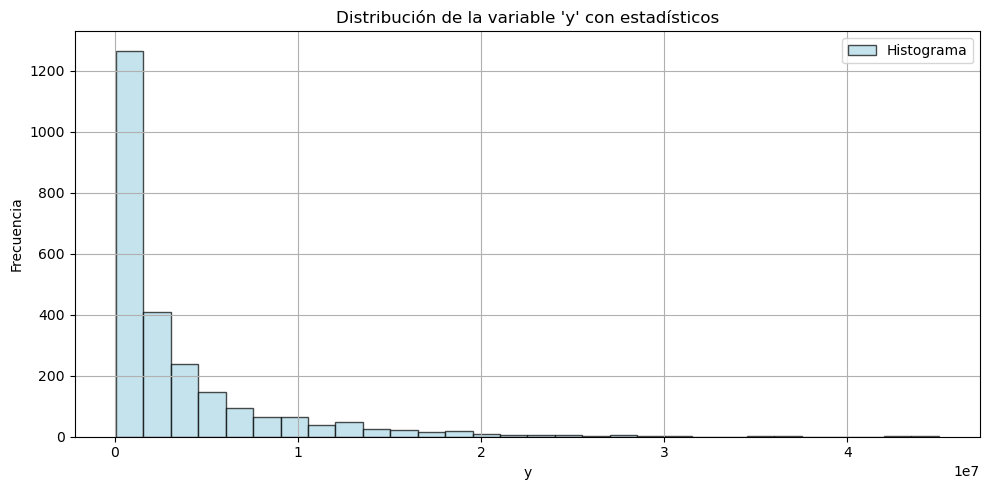

In [ ]:
# Estadísticos
media = np.mean(y)
mediana = np.median(y)
std_dev = np.std(y)
# Estadísticos
print(f"Media: {media:.2f}, Mediana: {mediana:.2f}, Desviación estándar: {std_dev:.2f}")

# Histograma con líneas
plt.figure(figsize=(10, 5))
plt.hist(y, bins=30, color='lightblue', edgecolor='black', alpha=0.7, label="Histograma")

# Líneas estadísticas
#plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f"Media: {media:,.0f}")
#plt.axvline(mediana, color='green', linestyle='-.', linewidth=2, label=f"Mediana: {mediana:,.0f}")
#plt.axvline(media + std_dev, color='orange', linestyle=':', linewidth=1.5, label=f"Media + 1σ")
#plt.axvline(media - std_dev, color='orange', linestyle=':', linewidth=1.5, label=f"Media - 1σ")

# Estética
plt.title("Distribución de la variable 'y' con estadísticos")
plt.xlabel("y")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Nuestro dataset tiene pinta de seguir una distribución de Poisson con lambda 1